In [ ]:
import kagglehub
path = kagglehub.dataset_download("mohammadamireshraghi/blood-cell-cancer-all-4class")
print("Path to dataset files:", path)

100%|██████████| 1.68G/1.68G [00:43<00:00, 41.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mohammadamireshraghi/blood-cell-cancer-all-4class/versions/1


In [ ]:
import tensorflow as tf
import numpy as np
import os

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Get the path from the previous step
dataset_path = "/root/.cache/kagglehub/datasets/mohammadamireshraghi/blood-cell-cancer-all-4class/versions/1/Blood cell Cancer [ALL]"

print(f"Loading images from: {dataset_path}")

# Create training, validation, and test datasets
# First, create a combined train+validation set and a 'raw' validation set to be split into val and test
# We'll use 80% for training, 10% for validation, and 10% for testing.
# To achieve this with image_dataset_from_directory, we'll split 80/20 initially, then split the 20% (validation set) into 10% validation and 10% test.

# Calculate the total number of images (this assumes a flat directory structure or counts all files)
# A more robust way would be to count files within the dataset_path, or let image_dataset_from_directory do a dry run.
# For now, let's assume image_dataset_from_directory will figure out the total number of samples.

# Create the training dataset (e.g., 80% of total)
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2, # 20% for validation and test combined initially
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Create the combined validation+test dataset (e.g., 20% of total)
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Determine the number of validation and test samples from val_test_ds
val_batches = tf.data.experimental.cardinality(val_test_ds).numpy()
if val_batches == -2: # -2 means unknown cardinality
    print("Warning: Cannot determine dataset cardinality directly. This might affect split accuracy.")
    print("Estimating dataset size by iterating through it. This might take a moment...")
    num_val_test_samples = 0
    for _ in val_test_ds:
        num_val_test_samples += BATCH_SIZE # Approximate count
    print(f"Estimated total samples in val_test_ds: {num_val_test_samples}")
    num_val_test_samples_per_batch = num_val_test_samples // BATCH_SIZE
else:
    num_val_test_samples_per_batch = val_batches

# Split the combined validation+test dataset into validation and test sets (e.g., 10% each)
# Assuming we want to split val_test_ds into two halves for val and test
num_val_samples_for_final_val = num_val_test_samples_per_batch // 2

validation_ds = val_test_ds.take(num_val_samples_for_final_val)
test_ds = val_test_ds.skip(num_val_samples_for_final_val)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds).numpy()}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

# Define a data augmentation layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

# Create a preprocessing function that rescales pixel values from [0, 255] to [0, 1]
def preprocess(image, label):
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

# Apply the data augmentation to the training dataset
augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

# Apply the preprocessing function to all datasets
train_ds_preprocessed = augmented_train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
validation_ds_preprocessed = validation_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_preprocessed = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Configure the datasets for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds_final = train_ds_preprocessed.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds_final = validation_ds_preprocessed.cache().prefetch(buffer_size=AUTOTUNE)
test_ds_final = test_ds_preprocessed.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets prepared: train_ds_final, validation_ds_final, test_ds_final")

Loading images from: /root/.cache/kagglehub/datasets/mohammadamireshraghi/blood-cell-cancer-all-4class/versions/1/Blood cell Cancer [ALL]
Found 3242 files belonging to 4 classes.
Using 2594 files for training.
Found 3242 files belonging to 4 classes.
Using 648 files for validation.
Number of training batches: 82
Number of validation batches: 10
Number of test batches: 11
Datasets prepared: train_ds_final, validation_ds_final, test_ds_final


In [ ]:
from tensorflow.keras.applications import ResNet50 # Changed from DenseNet121
from tensorflow.keras import layers, models

# Define the number of classes (as per the problem statement: 4-class classification)
num_classes = 4

# Step 3: Instantiate a pre-trained base model (ResNet50)
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)
base_model = ResNet50(input_shape=IMG_SHAPE,
                         include_top=False,
                         weights='imagenet')

print("Base model (ResNet50) loaded successfully.")

# Step 4: Freeze the layers of the base model
base_model.trainable = False

print("Base model layers frozen.")

# Step 5: Create a custom classification head
global_average_layer = layers.GlobalAveragePooling2D()
prediction_layer = layers.Dense(num_classes, activation='softmax')

# Build the custom head
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = global_average_layer(x)
x = layers.Dropout(0.2)(x) # Adding dropout for regularization
outputs = prediction_layer(x)

# Step 6: Combine the base model and the custom head
model = models.Model(inputs, outputs)

print("Combined model created.")

# Step 7: Print the model summary
print("Model Summary:")
model.summary()

# Step 8: Retrieve the class names from the train_ds object
class_names = train_ds.class_names
print(f"Class names: {class_names}")

Base model (ResNet50) loaded successfully.
Base model layers frozen.
Combined model created.
Model Summary:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Class names: ['Benign', '[Malignant] Pre-B', '[Malignant] Pro-B', '[Malignant] early Pre-B']


In [ ]:
print("Installing KerasTuner...")
!pip install keras-tuner
print("KerasTuner installed.")

Installing KerasTuner...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 8.9 MB/s eta 0:00:00
KerasTuner installed.


In [ ]:
import keras_tuner as kt
from tensorflow.keras.applications import ResNet50 # Import ResNet50

# Define the build_model function for KerasTuner
def build_model(hp):
    base_model_ht = ResNet50(input_shape=IMG_SHAPE,
                                include_top=False,
                                weights='imagenet')
    base_model_ht.trainable = False

    inputs = tf.keras.Input(shape=IMG_SHAPE)
    x = base_model_ht(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # Tune dropout rate
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
    x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model_ht = models.Model(inputs, outputs)

    # Tune learning rate for the optimizer
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model_ht.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  metrics=['accuracy'])

    return model_ht

# Instantiate the KerasTuner RandomSearch
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10, # Number of different hyperparameter combinations to try
    executions_per_trial=1, # Number of models to train for each trial
    directory='keras_tuner_dir', # Directory to store results
    project_name='resnet_transfer_learning' # Changed project name for ResNet
)

# Define EarlyStopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

print("Starting hyperparameter search...")
# Start the hyperparameter search
tuner.search(
    train_ds_final,
    epochs=10, # Number of epochs to train each model in the search
    validation_data=validation_ds_final,
    callbacks=[early_stopping]
)

print("Hyperparameter search completed.")

Trial 10 Complete [00h 01m 47s]
val_accuracy: 0.640625

Best val_accuracy So Far: 0.684374988079071
Total elapsed time: 00h 28m 13s
Hyperparameter search completed.


In [ ]:
print("Best hyperparameters found by KerasTuner:")
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Learning rate: {best_hps.get('learning_rate')}")
print(f"Dropout rate: {best_hps.get('dropout_rate')}")

Best hyperparameters found by KerasTuner:
Learning rate: 0.01
Dropout rate: 0.5


In [ ]:
# Get the best model from the tuner
best_model = tuner.get_best_models(num_models=1)[0]

# Compile the best model (it's already compiled with the best learning rate from build_model)

# Define callbacks for training
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# Train the best model
print("Training the best model...")
history = best_model.fit(
    train_ds_final,
    epochs=30, # A reasonable number of epochs, early stopping will prevent overfitting
    validation_data=validation_ds_final,
    callbacks=[early_stopping]
)

print("Best model trained successfully.")

Training the best model...
Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 193ms/step - accuracy: 0.4445 - loss: 1.2709 - val_accuracy: 0.5469 - val_loss: 0.9576
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.4830 - loss: 1.1924 - val_accuracy: 0.6156 - val_loss: 0.9196
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.4934 - loss: 1.1660 - val_accuracy: 0.6375 - val_loss: 0.9353
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.4942 - loss: 1.1848 - val_accuracy: 0.5000 - val_loss: 0.9670
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.4888 - loss: 1.1894 - val_accuracy: 0.5406 - val_loss: 0.9199
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.4861 - loss: 1.1948 - val_accuracy: 0.4750 - val_loss: 0.9818
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.4888 - loss: 1.1690 - val_accuracy: 0.5656 - val_loss: 0.9167
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.4719 - loss: 1.

In [ ]:
print("Evaluating the best model on the test set...")
loss, accuracy = best_model.evaluate(test_ds_final)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Evaluating the best model on the test set...
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 266ms/step - accuracy: 0.6250 - loss: 0.8565
Test Loss: 0.8565
Test Accuracy: 0.6250


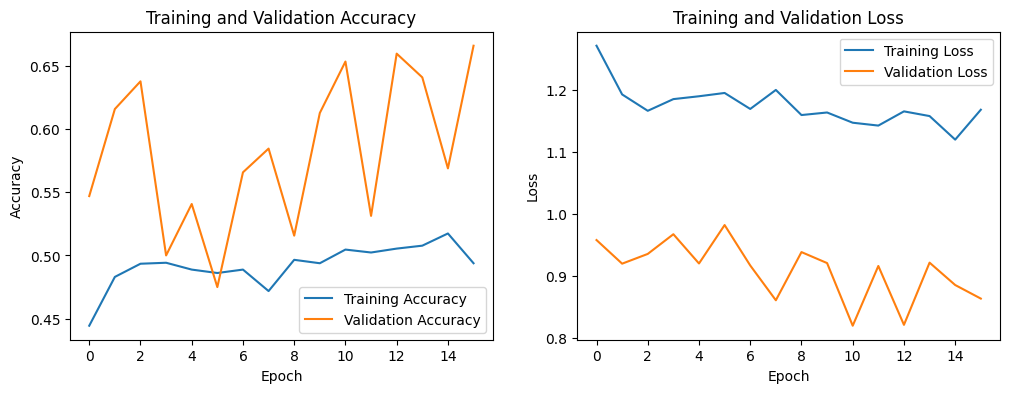

In [ ]:
import matplotlib.pyplot as plt

# Get the training history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = history.epoch

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 443ms/step
Generating Classification Report...
                         precision    recall  f1-score   support

                 Benign       0.79      0.20      0.32        55
      [Malignant] Pre-B       0.55      0.71      0.62        95
      [Malignant] Pro-B       0.83      0.92      0.87        73
[Malignant] early Pre-B       0.54      0.57      0.55       105

               accuracy                           0.62       328
              macro avg       0.68      0.60      0.59       328
           weighted avg       0.65      0.62      0.60       328

Generating Confusion Matrix...


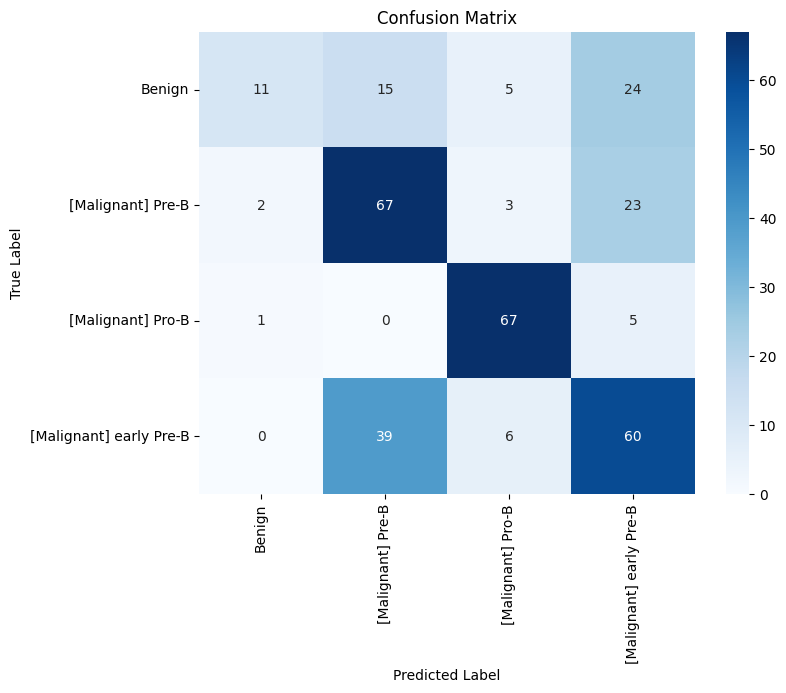

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Get true labels from the test dataset
y_true = np.concatenate([y for x, y in test_ds_final], axis=0)

# Get predictions from the model
y_pred_probs = best_model.predict(test_ds_final)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Generating Classification Report...")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Generating Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()